# CS3807 – Deep Learning Laboratory — Experiment 6
## End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

## 1. Setup, Imports, and Plotting Utilities

In [ ]:
# If running fresh, uncomment to make sure versions play nicely on Colab
!pip install -q tensorflow scikit-learn opencv-python-headless

import os, io, time, glob, zipfile, urllib.request, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, utils, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
print("Plots will be saved to:", os.path.abspath(PLOTS_DIR))


Plots will be saved to: /content/plots


In [ ]:
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['figure.dpi'] = 110

def style_axes(ax, title=None, xlabel=None, ylabel=None, legend=True, legend_loc='best'):
    """Apply bold title / axis labels / legend text to a matplotlib Axes."""
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
    if legend and ax.get_legend_handles_labels()[0]:
        leg = ax.legend(loc=legend_loc, prop={'weight': 'bold', 'size': 10})
    ax.grid(alpha=0.3)
    return ax

def save_fig(fig, name):
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print("Saved:", path)
    plt.show()


## 2. Dataset and Experimental Setup — UCI HAR (raw inertial signals)

We use the **raw inertial signal files** (not the precomputed 561-feature vectors), giving
9 channels × 128 time steps per window:
`total_acc_{x,y,z}`, `body_acc_{x,y,z}`, `body_gyro_{x,y,z}`.


In [ ]:
HAR_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
DATA_DIR = "har_data"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path = os.path.join(DATA_DIR, "har.zip")
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(HAR_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    # The archive nests another zip - "UCI HAR Dataset.zip"
    inner_zip = glob.glob(os.path.join(DATA_DIR, "**", "*.zip"), recursive=True)
    for iz in inner_zip:
        with zipfile.ZipFile(iz, 'r') as z:
            z.extractall(DATA_DIR)
    print("Done.")

HAR_ROOT = glob.glob(os.path.join(DATA_DIR, "**", "UCI HAR Dataset"), recursive=True)[0]
print("HAR root:", HAR_ROOT)


Done.
HAR root: har_data/UCI HAR Dataset


In [ ]:
SIGNALS = ['total_acc_x', 'total_acc_y', 'total_acc_z',
           'body_acc_x', 'body_acc_y', 'body_acc_z',
           'body_gyro_x', 'body_gyro_y', 'body_gyro_z']

ACTIVITY_NAMES = {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
                   4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}

def load_signals(subset):
    """subset = 'train' or 'test'. Returns X (N,128,9) and y (N,) 1-indexed labels."""
    signal_dir = os.path.join(HAR_ROOT, subset, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fpath = os.path.join(signal_dir, f"{sig}_{subset}.txt")
        arr = np.loadtxt(fpath)          # (N, 128)
        channels.append(arr)
    X = np.stack(channels, axis=-1)      # (N, 128, 9)
    y = np.loadtxt(os.path.join(HAR_ROOT, subset, f"y_{subset}.txt")).astype(int)
    return X, y

X_train_full, y_train_full = load_signals("train")
X_test_full, y_test_full   = load_signals("test")
print("Raw train:", X_train_full.shape, "Raw test:", X_test_full.shape)


Raw train: (7352, 128, 9) Raw test: (2947, 128, 9)


In [ ]:
# ---- Recommended laboratory subset: first 1500-3000 windows, all 6 classes, balanced ----
N_SUBSET = 3000

def stratified_subset(X, y, n_total, seed=SEED):
    classes = np.unique(y)
    per_class = n_total // len(classes)
    idxs = []
    rng = np.random.RandomState(seed)
    for c in classes:
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        idxs.extend(c_idx[:per_class])
    idxs = np.array(idxs)
    rng.shuffle(idxs)
    return X[idxs], y[idxs]

X_sub, y_sub = stratified_subset(X_train_full, y_train_full, N_SUBSET)
print("Subset used for the lab:", X_sub.shape, y_sub.shape)
print("Class distribution:", {ACTIVITY_NAMES[c]: int((y_sub == c).sum()) for c in np.unique(y_sub)})


Subset used for the lab: (3000, 128, 9) (3000,)
Class distribution: {'WALKING': 500, 'WALKING_UPSTAIRS': 500, 'WALKING_DOWNSTAIRS': 500, 'SITTING': 500, 'STANDING': 500, 'LAYING': 500}


In [ ]:
# ---- 70/15/15 train/val/test split, labels re-encoded 0-5 ----
y_sub_enc = y_sub - 1  # 0-indexed for sparse_categorical_crossentropy

X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub_enc, test_size=0.30, random_state=SEED, stratify=y_sub_enc)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# ---- Normalize using TRAIN statistics only ----
N_tr, T_len, F_ch = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F_ch))

def normalize(X):
    n, t, f = X.shape
    return scaler.transform(X.reshape(-1, f)).reshape(n, t, f)

X_train_n, X_val_n, X_test_n = normalize(X_train), normalize(X_val), normalize(X_test)

NUM_CLASSES = 6
CLASS_NAMES = [ACTIVITY_NAMES[i + 1] for i in range(NUM_CLASSES)]

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {F_ch}")
print(f"Sequence length: {T_len}")


Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


## 3. Temporal Data Visualization (Plot 1)

Sensor signal vs. time step, at least 3 channels, from 3 different activity classes.


Saved: plots/plot1_temporal_signals.png


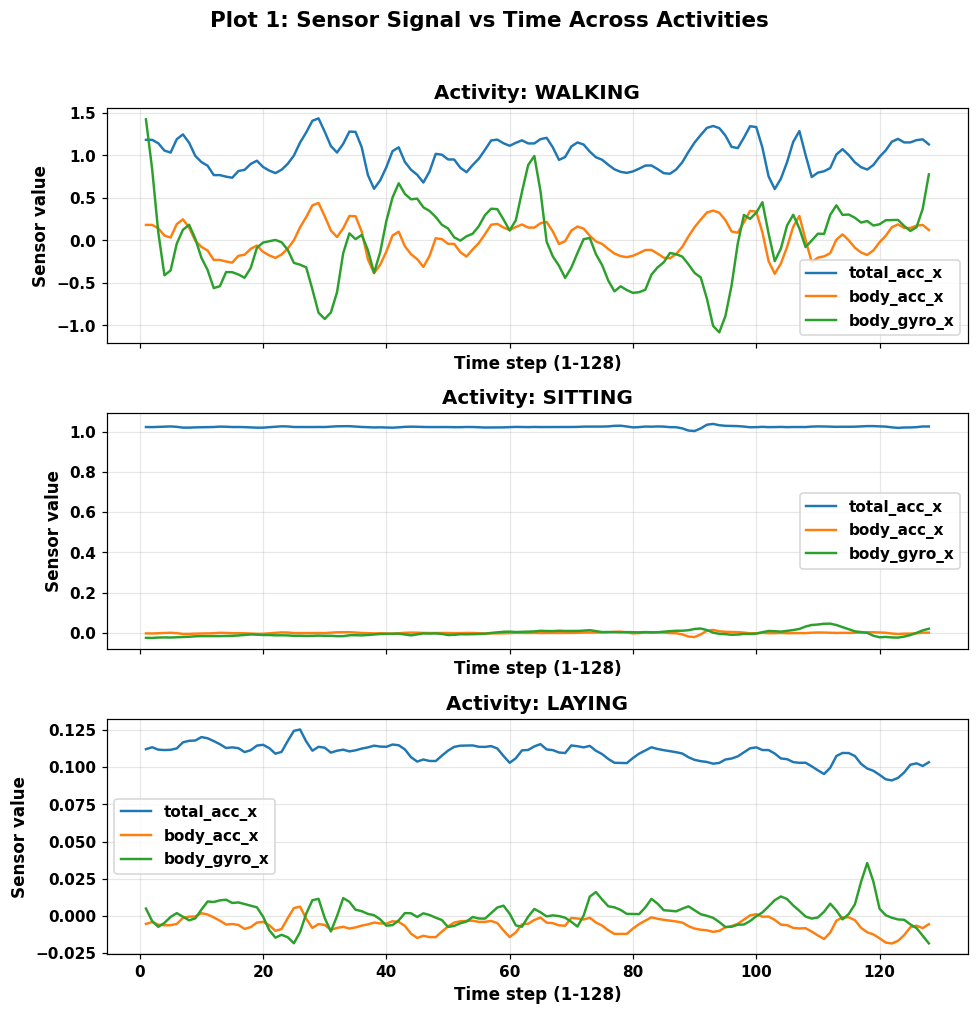

In [ ]:
def first_sample_of_class(X, y, class_idx):
    idx = np.where(y == class_idx)[0][0]
    return X[idx]

chosen_classes = [0, 3, 5]  # WALKING, SITTING, LAYING (indices into y_train, 0-indexed)
channels_to_plot = [0, 3, 6]  # total_acc_x, body_acc_x, body_gyro_x
channel_labels = ['total_acc_x', 'body_acc_x', 'body_gyro_x']

fig, axes = plt.subplots(len(chosen_classes), 1, figsize=(9, 9), sharex=True)
for ax, cls in zip(axes, chosen_classes):
    sample = first_sample_of_class(X_train, y_train, cls)
    for ch, lab in zip(channels_to_plot, channel_labels):
        ax.plot(range(1, T_len + 1), sample[:, ch], label=lab, linewidth=1.6)
    style_axes(ax, title=f"Activity: {CLASS_NAMES[cls]}", xlabel="Time step (1-128)",
               ylabel="Sensor value")
axes[-1].set_xlabel("Time step (1-128)", fontweight='bold')
fig.suptitle("Plot 1: Sensor Signal vs Time Across Activities", fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, "plot1_temporal_signals.png")


## 4. Backpropagation Through Time — Numerical Exercise

Given $x_1=0.5,\ x_2=0.7,\ x_3=0.2,\ h_0=0,\ W_x=0.5,\ W_h=0.8,\ b=0.1$ and
$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$, compute $h_1, h_2, h_3$ by hand, then verify with code.

**Manual calculation:**
- $h_1 = \tanh(0.5(0.5) + 0.8(0) + 0.1) = \tanh(0.35) \approx 0.3364$
- $h_2 = \tanh(0.5(0.7) + 0.8(0.3364) + 0.1) = \tanh(0.7191) \approx 0.6161$
- $h_3 = \tanh(0.5(0.2) + 0.8(0.6161) + 0.1) = \tanh(0.6929) \approx 0.5997$


In [ ]:
x = [0.5, 0.7, 0.2]
Wx, Wh, b = 0.5, 0.8, 0.1
h = 0.0
hs = []
for xt in x:
    h = np.tanh(Wx * xt + Wh * h + b)
    hs.append(h)

for i, val in enumerate(hs, start=1):
    print(f"h{i} = {val:.4f}")


h1 = 0.3364
h2 = 0.6164
h3 = 0.6000


## 5. Model Builder — Vanilla RNN / LSTM / GRU (identical protocol)

Same input, output layer, optimizer, batch size and evaluation protocol for all three, as required.


In [ ]:
RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30

def build_model(recurrent_type='SimpleRNN', units=RECURRENT_UNITS, input_shape=(T_len, F_ch),
                 num_layers=1, bidirectional=False):
    """recurrent_type in {'SimpleRNN','LSTM','GRU'}"""
    layer_cls = {'SimpleRNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}[recurrent_type]

    inputs = Input(shape=input_shape)
    x = inputs
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        rec_layer = layer_cls(units, return_sequences=return_seq)
        if bidirectional:
            rec_layer = layers.Bidirectional(rec_layer)
        x = rec_layer(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(DENSE_UNITS, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

build_model('SimpleRNN').summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train RNN, LSTM and GRU (Sections 9 & 12)

In [ ]:
results = {}       # results[model_name] = dict with history, metrics, etc.
trained_models = {}

def train_and_time(recurrent_type, X_tr, y_tr, X_va, y_va, epochs=EPOCHS, verbose=0, **build_kwargs):
    tf.keras.backend.clear_session()
    model = build_model(recurrent_type, input_shape=X_tr.shape[1:], **build_kwargs)
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                      epochs=epochs, batch_size=BATCH_SIZE, verbose=verbose)
    train_time = time.time() - t0
    n_params = model.count_params()
    return model, hist, train_time, n_params

for m in ['SimpleRNN', 'LSTM', 'GRU']:
    print(f"Training {m} ...")
    model, hist, ttime, nparams = train_and_time(m, X_train_n, y_train, X_val_n, y_val, verbose=0)
    trained_models[m] = model
    results[m] = {'history': hist.history, 'train_time': ttime, 'params': nparams}
    print(f"  {m}: params={nparams}, training_time={ttime:.1f}s, "
          f"final val_acc={hist.history['val_accuracy'][-1]:.4f}")


Training SimpleRNN ...
  SimpleRNN: params=1974, training_time=37.1s, final val_acc=0.8333
Training LSTM ...
  LSTM: params=6006, training_time=28.6s, final val_acc=0.9400
Training GRU ...
  GRU: params=4758, training_time=27.5s, final val_acc=0.9511


## 7. Required Training Plots (Plots 2 & 3) — one loss + one accuracy plot per model

Saved: plots/plot2_SimpleRNN_loss.png


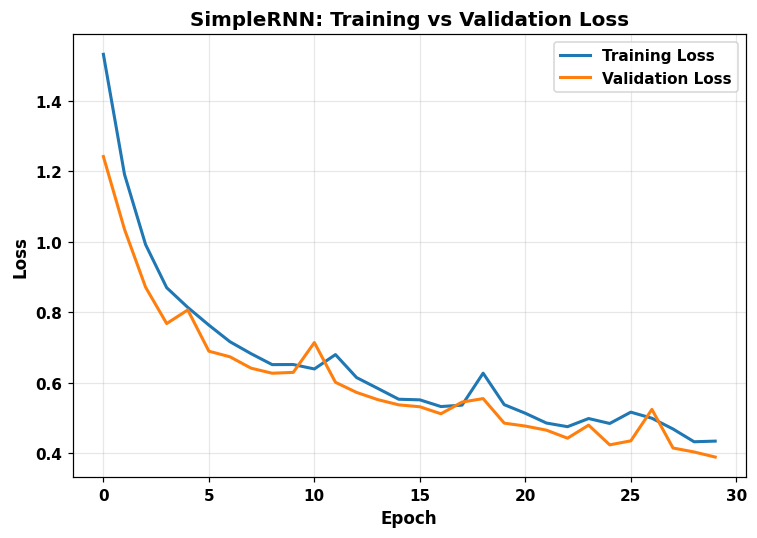

Saved: plots/plot3_SimpleRNN_accuracy.png


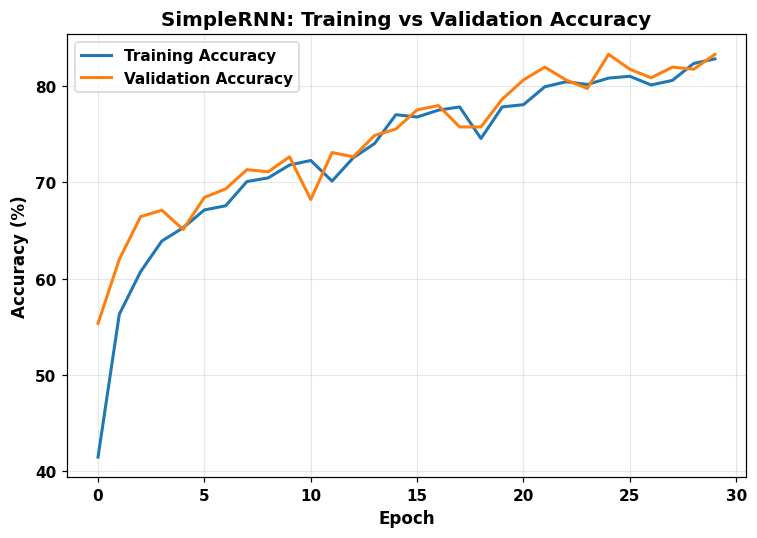

Saved: plots/plot2_LSTM_loss.png


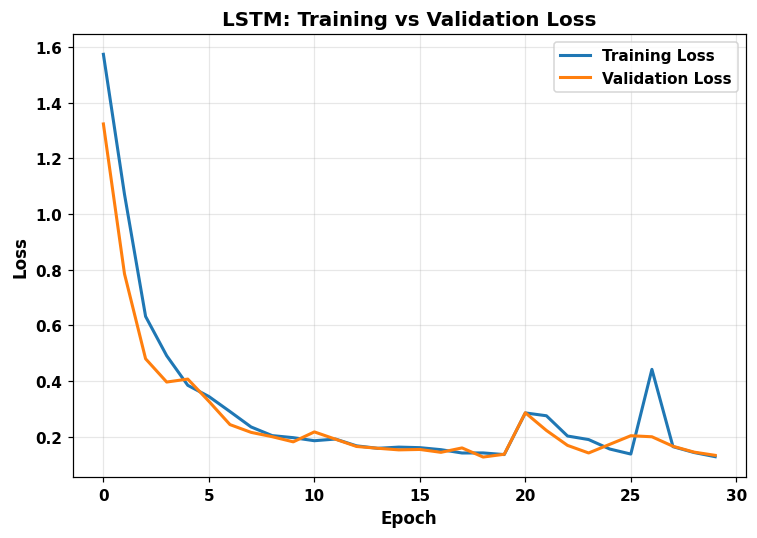

Saved: plots/plot3_LSTM_accuracy.png


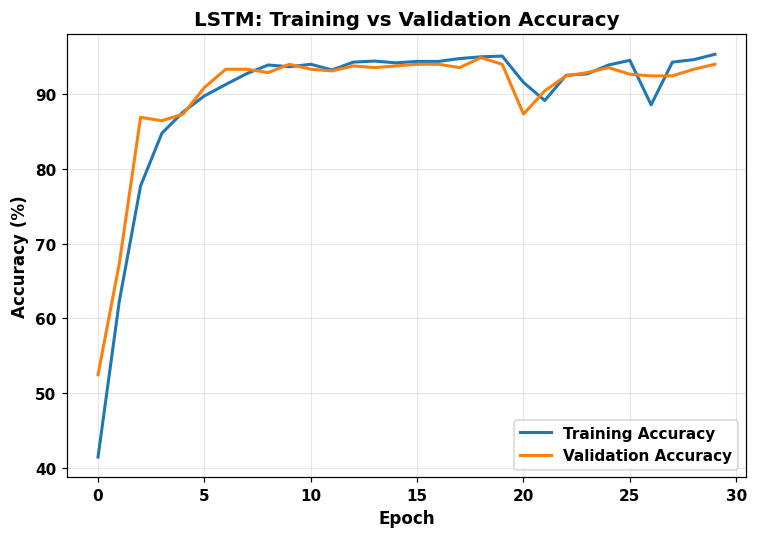

Saved: plots/plot2_GRU_loss.png


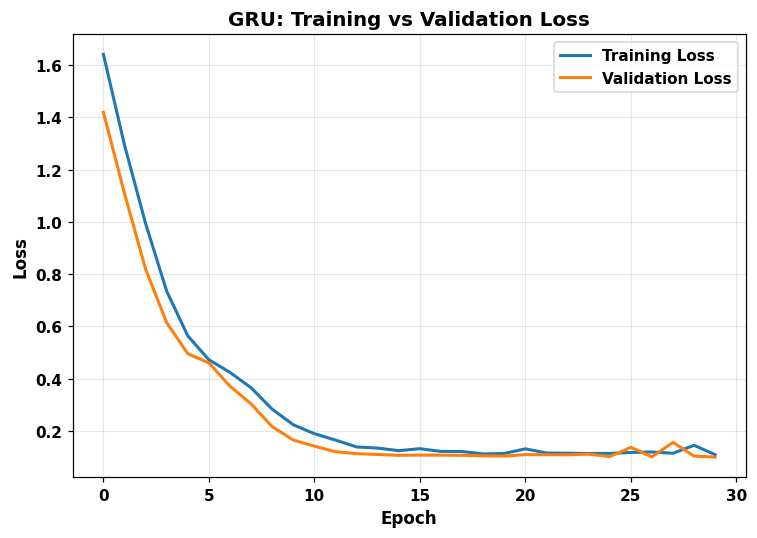

Saved: plots/plot3_GRU_accuracy.png


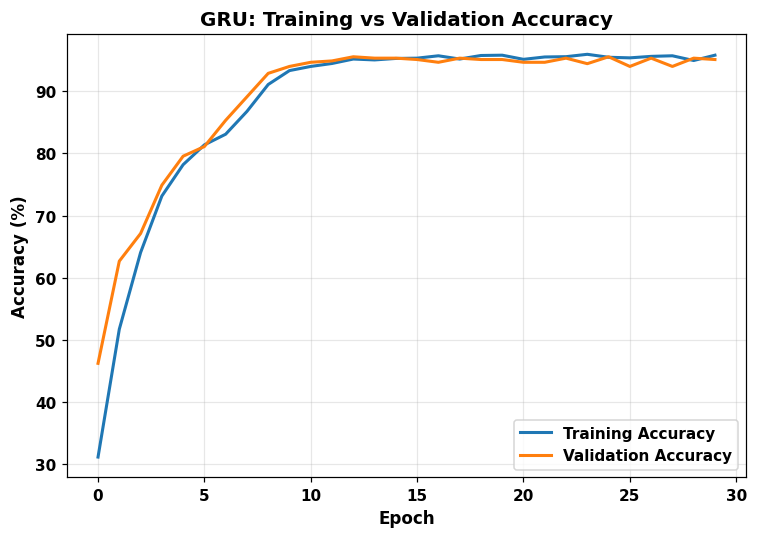

In [ ]:
for m in ['SimpleRNN', 'LSTM', 'GRU']:
    hist = results[m]['history']

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(hist['loss'], label='Training Loss', linewidth=2)
    ax.plot(hist['val_loss'], label='Validation Loss', linewidth=2)
    style_axes(ax, title=f"{m}: Training vs Validation Loss", xlabel="Epoch", ylabel="Loss")
    fig.tight_layout()
    save_fig(fig, f"plot2_{m}_loss.png")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(np.array(hist['accuracy']) * 100, label='Training Accuracy', linewidth=2)
    ax.plot(np.array(hist['val_accuracy']) * 100, label='Validation Accuracy', linewidth=2)
    style_axes(ax, title=f"{m}: Training vs Validation Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    fig.tight_layout()
    save_fig(fig, f"plot3_{m}_accuracy.png")


## 8. Performance Evaluation on Test Set

In [ ]:
def evaluate_model(model, X_te, y_te, class_names=CLASS_NAMES):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_te, y_pred)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'cm': cm,
            'y_pred': y_pred, 'probs': y_prob}

eval_table_rows = []
for m in ['SimpleRNN', 'LSTM', 'GRU']:
    ev = evaluate_model(trained_models[m], X_test_n, y_test)
    results[m].update(ev)
    eval_table_rows.append({
        'Model': m,
        'Accuracy (%)': round(ev['accuracy'] * 100, 2),
        'Macro Precision (%)': round(ev['precision'] * 100, 2),
        'Macro Recall (%)': round(ev['recall'] * 100, 2),
        'Macro F1 (%)': round(ev['f1'] * 100, 2),
        'Parameters': results[m]['params'],
        'Training Time (s)': round(results[m]['train_time'], 1),
    })

eval_df = pd.DataFrame(eval_table_rows)
eval_df


,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,SimpleRNN,80.44,81.24,80.44,80.42,1974,37.1
1,LSTM,94.00,94.04,94.00,93.99,6006,28.6
2,GRU,96.67,96.67,96.67,96.67,4758,27.5


## 9. Confusion Matrix Analysis (Plot 4)

Saved: plots/plot4_confusion_SimpleRNN.png


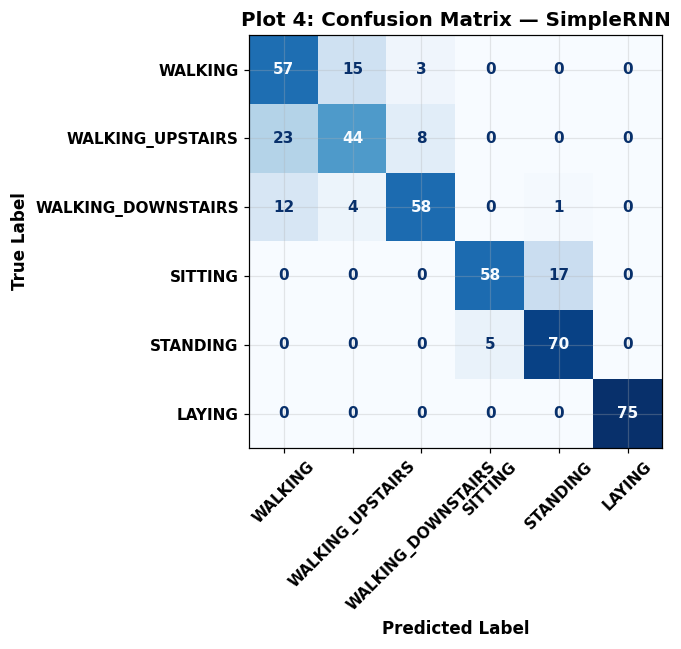

Saved: plots/plot4_confusion_LSTM.png


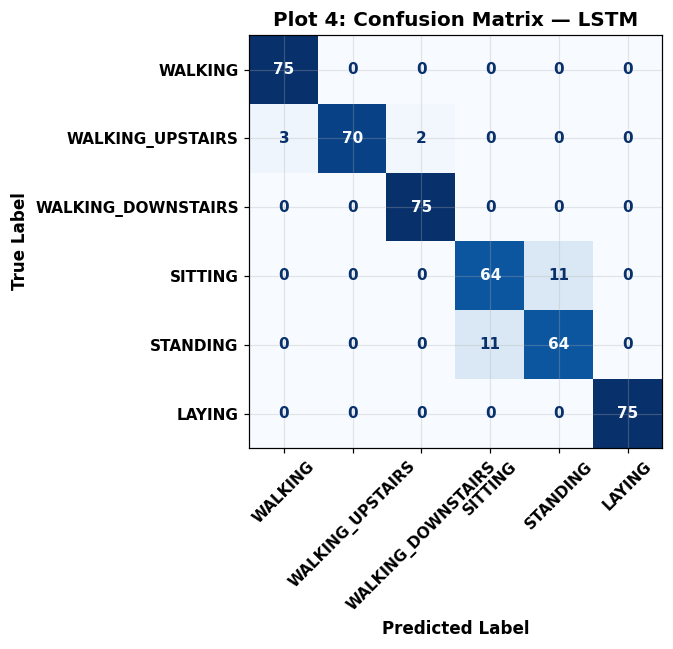

Saved: plots/plot4_confusion_GRU.png


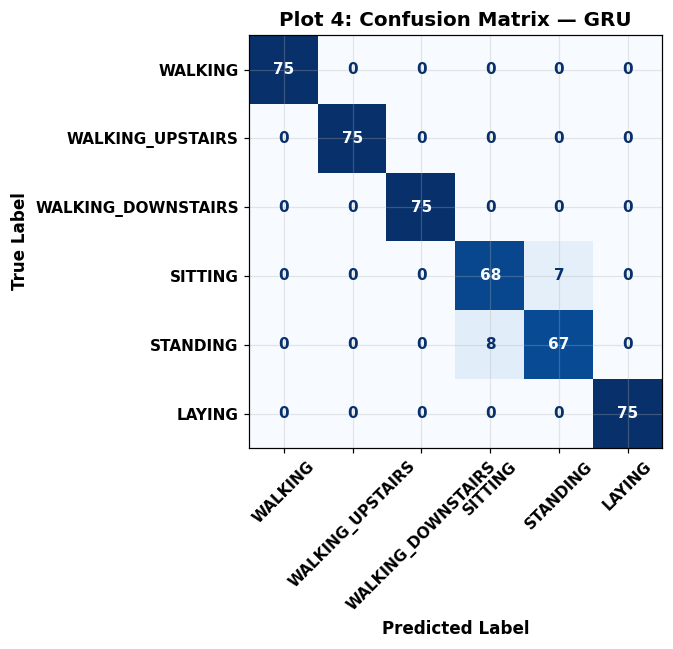

In [ ]:
for m in ['SimpleRNN', 'LSTM', 'GRU']:
    cm = results[m]['cm']
    fig, ax = plt.subplots(figsize=(6.5, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    for text in ax.texts:
        text.set_fontweight('bold')
    style_axes(ax, title=f"Plot 4: Confusion Matrix — {m}", xlabel="Predicted Label",
               ylabel="True Label", legend=False)
    fig.tight_layout()
    save_fig(fig, f"plot4_confusion_{m}.png")


In [ ]:
for m in ['SimpleRNN', 'LSTM', 'GRU']:
    cm = results[m]['cm']
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    best = CLASS_NAMES[np.argmax(per_class_acc)]
    worst = CLASS_NAMES[np.argmin(per_class_acc)]
    off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)
    i, j = np.unravel_index(np.argmax(off_diag), off_diag.shape)
    print(f"{m}: best-recognized={best} ({per_class_acc.max()*100:.1f}%), "
          f"worst-recognized={worst} ({per_class_acc.min()*100:.1f}%), "
          f"most-confused pair: {CLASS_NAMES[i]} -> predicted as {CLASS_NAMES[j]} "
          f"({off_diag[i,j]} instances)")


SimpleRNN: best-recognized=LAYING (100.0%), worst-recognized=WALKING_UPSTAIRS (58.7%), most-confused pair: WALKING_UPSTAIRS -> predicted as WALKING (23 instances)
LSTM: best-recognized=WALKING (100.0%), worst-recognized=SITTING (85.3%), most-confused pair: SITTING -> predicted as STANDING (11 instances)
GRU: best-recognized=WALKING (100.0%), worst-recognized=STANDING (89.3%), most-confused pair: STANDING -> predicted as SITTING (8 instances)


## 10. RNN vs LSTM vs GRU — Comparison Table (Section 16)

In [ ]:
comparison_table = pd.DataFrame({
    'Property': ['Hidden state', 'Cell state', 'Forget gate', 'Input gate', 'Output gate',
                 'Update gate', 'Reset gate', 'Parameters', 'Training time (s)', 'Test F1-score (%)'],
    'RNN':  ['Yes', 'No', 'No', 'No', 'No', 'No', 'No',
             results['SimpleRNN']['params'], round(results['SimpleRNN']['train_time'], 1),
             round(results['SimpleRNN']['f1'] * 100, 2)],
    'LSTM': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No',
             results['LSTM']['params'], round(results['LSTM']['train_time'], 1),
             round(results['LSTM']['f1'] * 100, 2)],
    'GRU':  ['Yes', 'No', 'No', 'No', 'No', 'Yes', 'Yes',
             results['GRU']['params'], round(results['GRU']['train_time'], 1),
             round(results['GRU']['f1'] * 100, 2)],
})
comparison_table


,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time (s),37.1,28.6,27.5
9,Test F1-score (%),80.42,93.99,96.67


## 11. Model Performance Comparison — Bar Plot (Plot 5)

Saved: plots/plot5_model_comparison.png


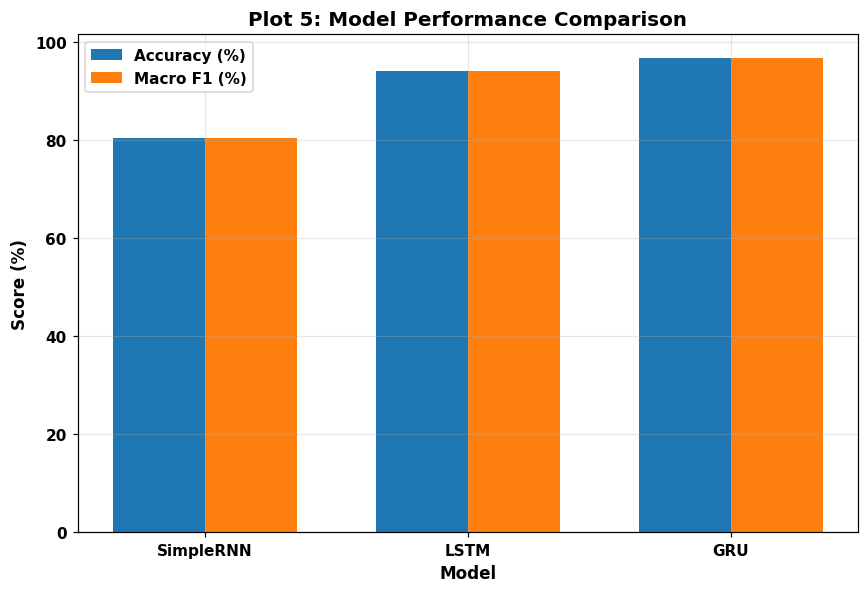

Saved: plots/plot5b_computational_comparison.png


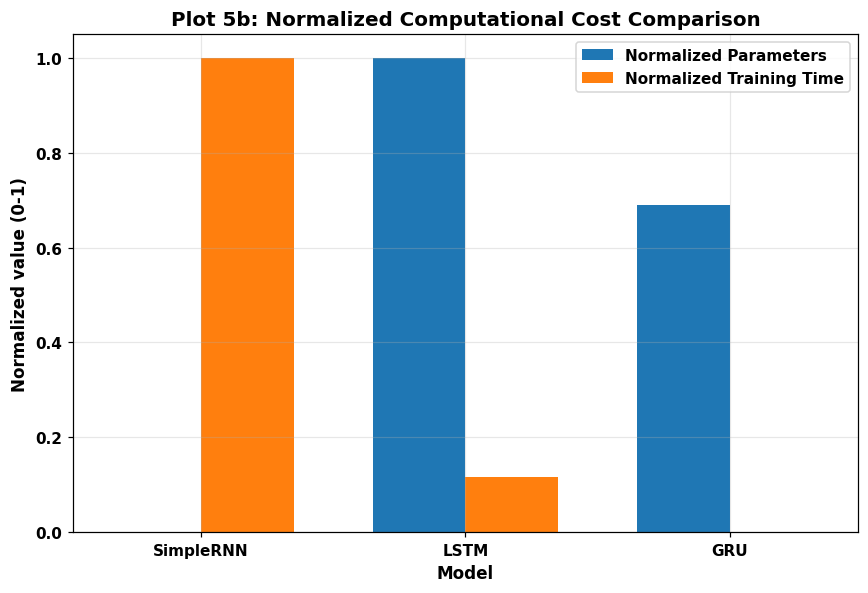

In [ ]:
metrics_to_plot = ['Accuracy (%)', 'Macro F1 (%)']
models_order = ['SimpleRNN', 'LSTM', 'GRU']
x = np.arange(len(models_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5.5))
for i, metric in enumerate(metrics_to_plot):
    vals = [eval_df.loc[eval_df['Model'] == m, metric].values[0] for m in models_order]
    ax.bar(x + (i - 0.5) * width, vals, width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(models_order, fontweight='bold')
style_axes(ax, title="Plot 5: Model Performance Comparison", xlabel="Model",
           ylabel="Score (%)")
fig.tight_layout()
save_fig(fig, "plot5_model_comparison.png")

# Normalized computational comparison (params & time, min-max scaled to [0,1] for readability)
fig, ax = plt.subplots(figsize=(8, 5.5))
params = np.array([results[m]['params'] for m in models_order], dtype=float)
times = np.array([results[m]['train_time'] for m in models_order], dtype=float)
params_norm = (params - params.min()) / (np.ptp(params) + 1e-9)
times_norm = (times - times.min()) / (np.ptp(times) + 1e-9)
ax.bar(x - width/2, params_norm, width, label='Normalized Parameters')
ax.bar(x + width/2, times_norm, width, label='Normalized Training Time')
ax.set_xticks(x)
ax.set_xticklabels(models_order, fontweight='bold')
style_axes(ax, title="Plot 5b: Normalized Computational Cost Comparison",
           xlabel="Model", ylabel="Normalized value (0-1)")
fig.tight_layout()
save_fig(fig, "plot5b_computational_comparison.png")


## 12. Effect of Sequence Length (Section 17, Plot 6)

Repeat training with truncated sequence lengths $T \in \{32, 64, 128\}$ (consistently for all
three models), and plot test macro-F1 vs. sequence length.


In [ ]:
def truncate_seq(X, T):
    """Take the first T time steps."""
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_results = {m: [] for m in ['SimpleRNN', 'LSTM', 'GRU']}

for T_use in seq_lengths:
    Xtr_t = truncate_seq(X_train_n, T_use)
    Xva_t = truncate_seq(X_val_n, T_use)
    Xte_t = truncate_seq(X_test_n, T_use)
    for m in ['SimpleRNN', 'LSTM', 'GRU']:
        model, hist, ttime, nparams = train_and_time(m, Xtr_t, y_train, Xva_t, y_val,
                                                       epochs=EPOCHS, verbose=0)
        ev = evaluate_model(model, Xte_t, y_test)
        seqlen_results[m].append(ev['f1'])
        print(f"T={T_use:3d}  {m:9s}  Test Macro-F1 = {ev['f1']*100:.2f}%")

seqlen_table = pd.DataFrame({'Sequence Length': seq_lengths,
                              'RNN F1': [round(v*100,2) for v in seqlen_results['SimpleRNN']],
                              'LSTM F1': [round(v*100,2) for v in seqlen_results['LSTM']],
                              'GRU F1': [round(v*100,2) for v in seqlen_results['GRU']]})
seqlen_table


T= 32  SimpleRNN  Test Macro-F1 = 72.26%
T= 32  LSTM       Test Macro-F1 = 92.84%
T= 32  GRU        Test Macro-F1 = 94.21%
T= 64  SimpleRNN  Test Macro-F1 = 77.27%
T= 64  LSTM       Test Macro-F1 = 94.19%
T= 64  GRU        Test Macro-F1 = 93.85%
T=128  SimpleRNN  Test Macro-F1 = 85.39%
T=128  LSTM       Test Macro-F1 = 95.54%
T=128  GRU        Test Macro-F1 = 95.11%


,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,72.26,92.84,94.21
1,64,77.27,94.19,93.85
2,128,85.39,95.54,95.11


Saved: plots/plot6_seqlen_vs_f1.png


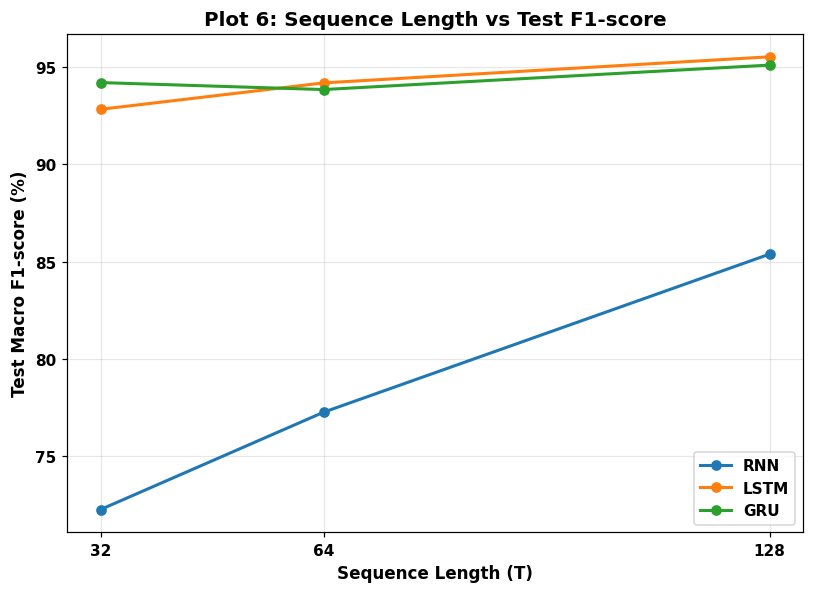

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for m, label in zip(['SimpleRNN', 'LSTM', 'GRU'], ['RNN', 'LSTM', 'GRU']):
    ax.plot(seq_lengths, np.array(seqlen_results[m]) * 100, marker='o', linewidth=2, label=label)
style_axes(ax, title="Plot 6: Sequence Length vs Test F1-score", xlabel="Sequence Length (T)",
           ylabel="Test Macro F1-score (%)")
ax.set_xticks(seq_lengths)
fig.tight_layout()
save_fig(fig, "plot6_seqlen_vs_f1.png")


## 13. Video Understanding Using CNN + RNN (Sections 18–21)

### Getting a small UCF101 subset

Run the shell cell below **once**. It downloads the official UCF101 archive (~6.9 GB) — for a lab
subset, instead use the smaller pre-split "UCF101 subset" mirrors, or manually place a handful of
`.avi` files for 3–5 classes (e.g. `Basketball`, `Biking`, `Walking`, `Running`, `TennisSwing`) into
`ucf101_subset/<ClassName>/*.avi`. The code below works with **any** folder laid out that way, so
you can populate it either by downloading a couple of classes from the official split or by copying
a handful of videos you already have.


In [ ]:
import os, shutil, glob
import pandas as pd

# 1) Download a small, genuine UCF101 subset (reliable Google-hosted mirror)
!wget -q https://git.io/JGc31 -O ucf101_top5.tar.gz
!tar xf ucf101_top5.tar.gz

print("Extracted contents:", os.listdir("."))

Extracted contents: ['.config', 'train.csv', 'plots', 'ucf101_top5.tar.gz', 'UCF101.rar', 'ucf101_subset', 'train', 'test.csv', 'har_data', 'test', 'sample_data']


In [ ]:
import os, shutil, pandas as pd

# These are the actual classes available in this dataset
SELECTED_CLASSES = ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']
VIDEOS_PER_CLASS = 15   # "small number of videos per class" per the manual

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
all_df = pd.concat([train_df, test_df], ignore_index=True)

os.makedirs("ucf101_subset", exist_ok=True)

for cls in SELECTED_CLASSES:
    dst = os.path.join("ucf101_subset", cls)
    os.makedirs(dst, exist_ok=True)

    cls_rows = all_df[all_df['tag'] == cls].sample(
        n=min(VIDEOS_PER_CLASS, len(all_df[all_df['tag'] == cls])),
        random_state=42
    )

    copied = 0
    for _, row in cls_rows.iterrows():
        fname = row['video_name']
        # video could be in either train/ or test/
        for folder in ["train", "test"]:
            src_path = os.path.join(folder, fname)
            if os.path.exists(src_path):
                shutil.copy(src_path, os.path.join(dst, fname))
                copied += 1
                break
    print(f"Copied {cls}: {copied} videos")

print("\nFinal ucf101_subset/ contents:")
for cls in SELECTED_CLASSES:
    print(f"  {cls}: {len(os.listdir(os.path.join('ucf101_subset', cls)))} files")

Copied CricketShot: 15 videos
Copied PlayingCello: 15 videos
Copied Punch: 15 videos
Copied ShavingBeard: 15 videos
Copied TennisSwing: 15 videos

Final ucf101_subset/ contents:
  CricketShot: 15 files
  PlayingCello: 15 files
  Punch: 15 files
  ShavingBeard: 15 files
  TennisSwing: 15 files


In [ ]:
VIDEO_ROOT = "ucf101_subset"   # expected layout: ucf101_subset/<ClassName>/*.avi (or .mp4)
SELECTED_CLASSES = ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']
N_FRAMES = 10
FRAME_SIZE = (224, 224)

# 1) Install the unrar utility (not present by default)
!apt-get -qq install unrar > /dev/null

# 2) Download and extract the full UCF101 archive
!wget -q https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
!unrar x -y UCF101.rar > /dev/null

# 3) Keep only a SMALL subset per class, in the folder structure the notebook expects
import os, shutil, random

random.seed(42)
VIDEOS_PER_CLASS = 15   # "small number of videos per class" per the manual

os.makedirs("ucf101_subset", exist_ok=True)
for cls in SELECTED_CLASSES:
    src = os.path.join("UCF-101", cls)
    dst = os.path.join("ucf101_subset", cls)
    if os.path.isdir(src):
        os.makedirs(dst, exist_ok=True)
        all_vids = os.listdir(src)
        random.shuffle(all_vids)
        chosen = all_vids[:VIDEOS_PER_CLASS]
        for v in chosen:
            shutil.copy(os.path.join(src, v), os.path.join(dst, v))
        print(f"Copied {cls}: {len(chosen)} videos")
    else:
        print(f"WARNING: class folder '{cls}' not found in UCF-101/")

# 4) Free up disk space — delete the full archive and the other 96 classes
shutil.rmtree("UCF-101", ignore_errors=True)
os.remove("UCF101.rar")

os.makedirs(VIDEO_ROOT, exist_ok=True)
found_classes = [d for d in SELECTED_CLASSES if os.path.isdir(os.path.join(VIDEO_ROOT, d))]
print("Classes found on disk:", found_classes if found_classes else "NONE YET — see instructions above.")


Classes found on disk: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']


In [ ]:
import cv2

def sample_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frames.append(frame)
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.stack(frames[:n_frames])  # (n_frames, 224, 224, 3)

def load_video_dataset(video_root, classes, n_frames=N_FRAMES):
    X_frames, y_labels, paths = [], [], []
    for ci, cls in enumerate(classes):
        cls_dir = os.path.join(video_root, cls)
        if not os.path.isdir(cls_dir):
            continue
        vids = glob.glob(os.path.join(cls_dir, "*.avi")) + glob.glob(os.path.join(cls_dir, "*.mp4"))
        for vp in vids:
            frames = sample_frames(vp, n_frames)
            if frames is not None:
                X_frames.append(frames)
                y_labels.append(ci)
                paths.append(vp)
    if not X_frames:
        return None, None, None
    return np.stack(X_frames), np.array(y_labels), paths

video_classes = found_classes if found_classes else SELECTED_CLASSES
X_vid_frames, y_vid, vid_paths = load_video_dataset(VIDEO_ROOT, video_classes)
if X_vid_frames is None:
    print("No videos found under 'ucf101_subset/'. Populate the folder as described above, "
          "then re-run this cell before continuing with Sections 13.2 onward.")
else:
    print("Loaded frames tensor:", X_vid_frames.shape, "  labels:", y_vid.shape)


Loaded frames tensor: (71, 10, 224, 224, 3)   labels: (71,)


### Plot 7: Video Sample Frames

Saved: plots/plot7_video_sample_frames.png


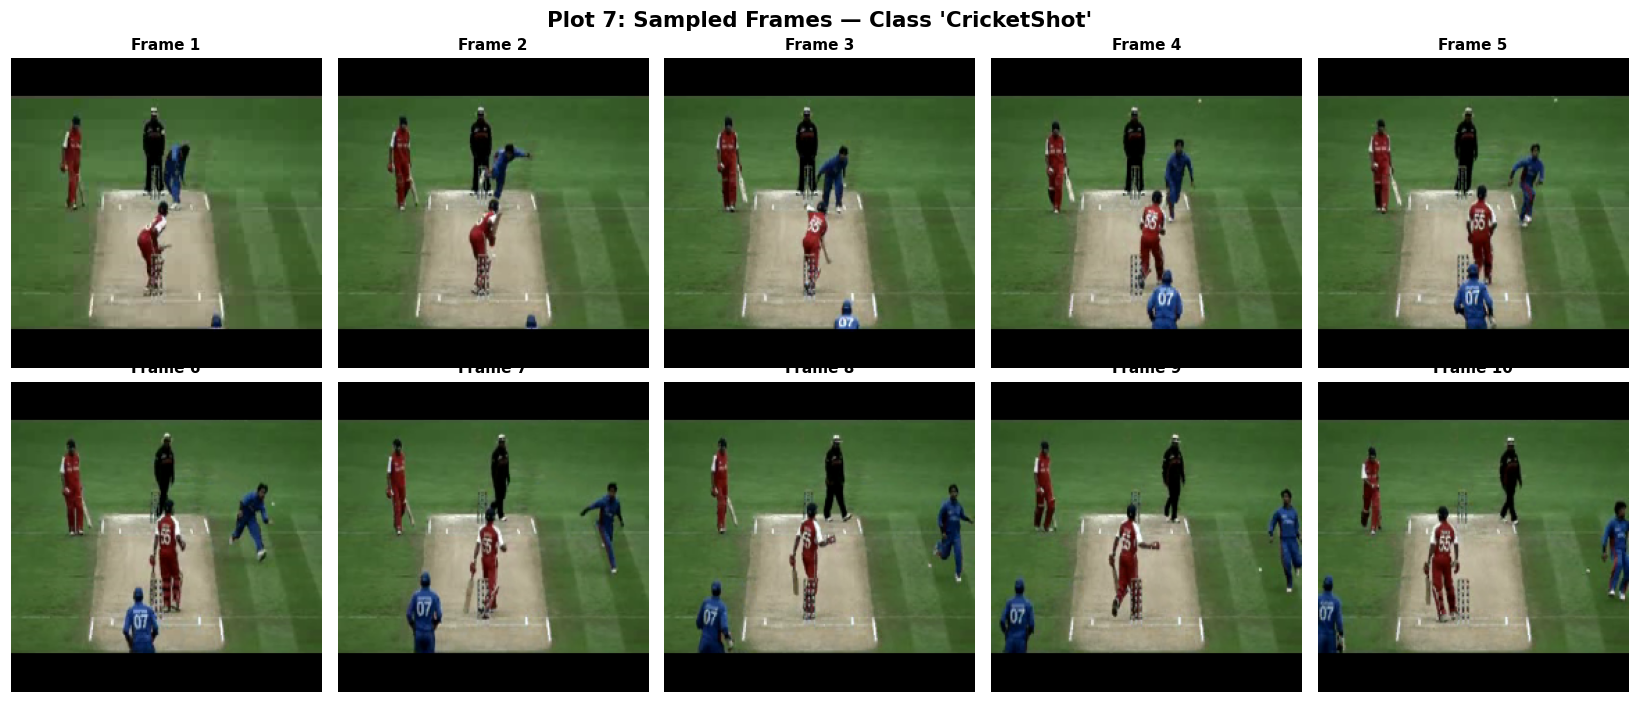

In [ ]:
if X_vid_frames is not None:
    sample_idx = 0
    frames = X_vid_frames[sample_idx]
    fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(frames[i])
        ax.set_title(f"Frame {i+1}", fontsize=10, fontweight='bold')
        ax.axis('off')
    fig.suptitle(f"Plot 7: Sampled Frames — Class '{video_classes[y_vid[sample_idx]]}'",
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, "plot7_video_sample_frames.png")
else:
    print("Skipped: no video data loaded yet.")


### CNN Feature Extraction (Section 20)

A frozen, pretrained MobileNetV2 (classification head removed, global average pooling) is used
purely as a spatial feature extractor — it is **not** trained.


In [ ]:
if X_vid_frames is not None:
    cnn_extractor = MobileNetV2(include_top=False, weights='imagenet', pooling='avg',
                                 input_shape=(224, 224, 3))
    cnn_extractor.trainable = False   # freeze

    def extract_features(frame_batch):
        """frame_batch: (B, n_frames, 224, 224, 3) uint8 -> (B, n_frames, D) features"""
        B, nF, H, W, C = frame_batch.shape
        flat = frame_batch.reshape(-1, H, W, C).astype('float32')
        flat = preprocess_input(flat)
        feats = cnn_extractor.predict(flat, batch_size=32, verbose=0)
        D = feats.shape[-1]
        return feats.reshape(B, nF, D), D

    X_vid_feats, FEAT_DIM = extract_features(X_vid_frames)
    print("CNN feature dimension D =", FEAT_DIM)
    print("Feature tensor supplied to the recurrent network:", X_vid_feats.shape)
else:
    print("Skipped: no video data loaded yet.")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN feature dimension D = 1280
Feature tensor supplied to the recurrent network: (71, 10, 1280)


### CNN–LSTM / CNN–GRU Classifier (Section 21) + Plots 8 & 9

In [ ]:
def build_video_classifier(recurrent_type, feat_dim, n_frames, n_classes):
    layer_cls = {'LSTM': layers.LSTM, 'GRU': layers.GRU}[recurrent_type]
    inputs = Input(shape=(n_frames, feat_dim))
    x = layer_cls(32)(inputs)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

video_results = {}
if X_vid_frames is not None and len(np.unique(y_vid)) > 1:
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(X_vid_feats, y_vid, test_size=0.25,
                                                   random_state=SEED, stratify=y_vid)
    Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(Xv_tr, yv_tr, test_size=0.2,
                                                   random_state=SEED, stratify=yv_tr)
    n_vid_classes = len(np.unique(y_vid))

    for rec_type in ['LSTM', 'GRU']:
        tf.keras.backend.clear_session()
        vmodel = build_video_classifier(rec_type, FEAT_DIM, N_FRAMES, n_vid_classes)
        vhist = vmodel.fit(Xv_tr, yv_tr, validation_data=(Xv_va, yv_va),
                            epochs=30, batch_size=8, verbose=0)
        vev = evaluate_model(vmodel, Xv_te, yv_te, class_names=video_classes)
        video_results[rec_type] = {'history': vhist.history, **vev}
        print(f"CNN-{rec_type}: test accuracy={vev['accuracy']*100:.2f}%, "
              f"macro-F1={vev['f1']*100:.2f}%")
else:
    print("Skipped: need real video data across >1 class to train the CNN-RNN classifier.")


CNN-LSTM: test accuracy=88.89%, macro-F1=86.03%
CNN-GRU: test accuracy=88.89%, macro-F1=88.06%


Saved: plots/plot8_video_LSTM_curves.png


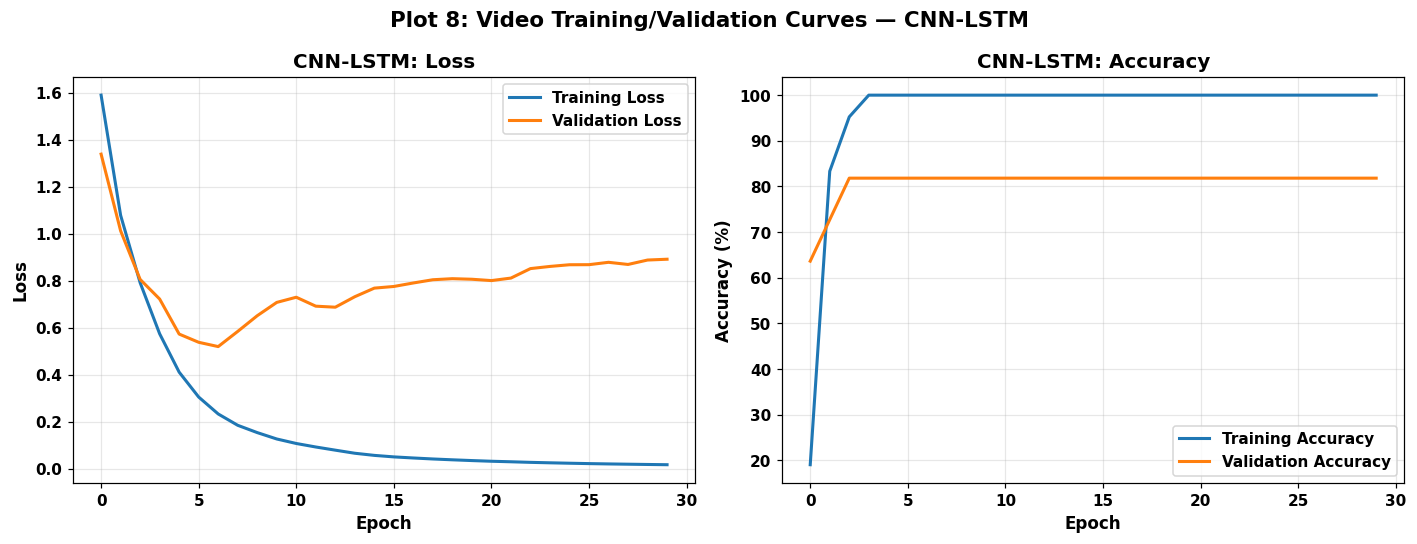

Saved: plots/plot9_video_confusion_LSTM.png


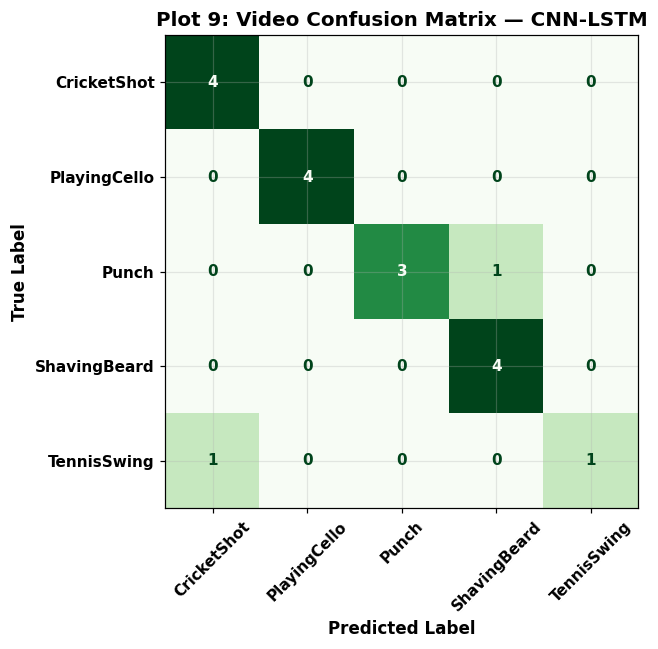

Saved: plots/plot8_video_GRU_curves.png


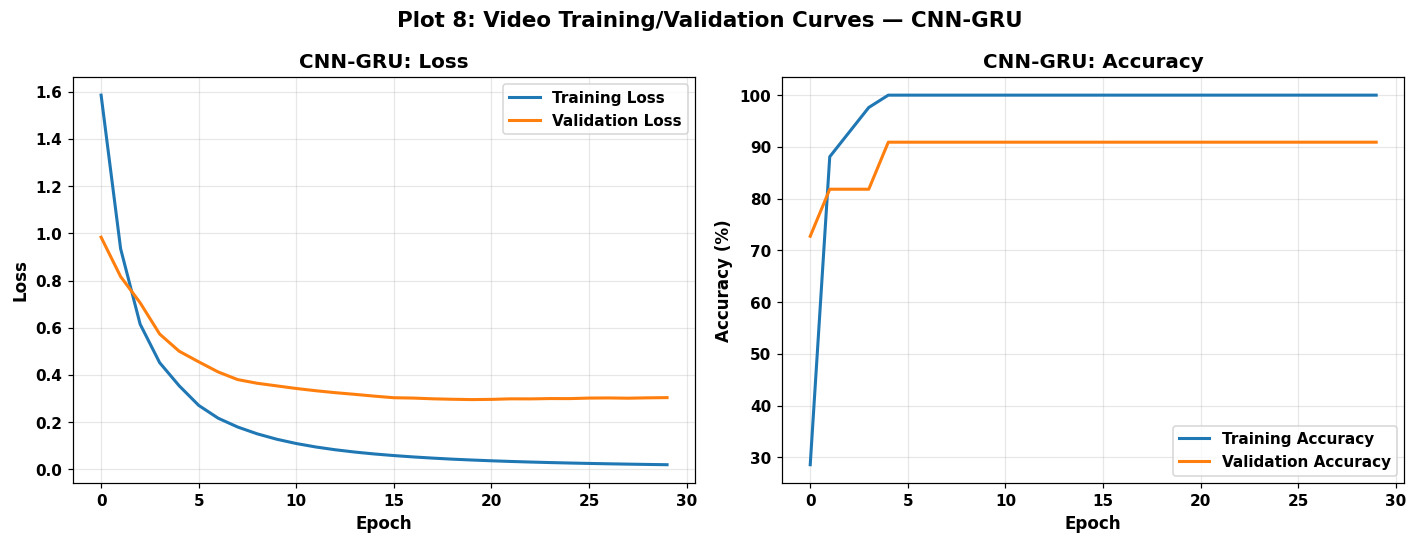

Saved: plots/plot9_video_confusion_GRU.png


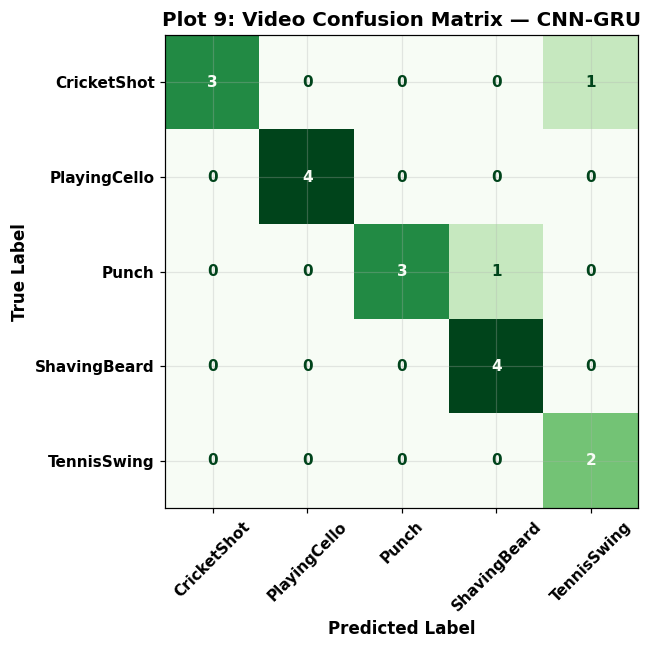

In [ ]:
for rec_type in video_results:
    hist = video_results[rec_type]['history']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(hist['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(hist['val_loss'], label='Validation Loss', linewidth=2)
    style_axes(axes[0], title=f"CNN-{rec_type}: Loss", xlabel="Epoch", ylabel="Loss")

    axes[1].plot(np.array(hist['accuracy'])*100, label='Training Accuracy', linewidth=2)
    axes[1].plot(np.array(hist['val_accuracy'])*100, label='Validation Accuracy', linewidth=2)
    style_axes(axes[1], title=f"CNN-{rec_type}: Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")

    fig.suptitle(f"Plot 8: Video Training/Validation Curves — CNN-{rec_type}",
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, f"plot8_video_{rec_type}_curves.png")

    cm = video_results[rec_type]['cm']
    fig, ax = plt.subplots(figsize=(6.5, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=video_classes[:cm.shape[0]])
    disp.plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=45)
    for text in ax.texts:
        text.set_fontweight('bold')
    style_axes(ax, title=f"Plot 9: Video Confusion Matrix — CNN-{rec_type}",
               xlabel="Predicted Label", ylabel="True Label", legend=False)
    fig.tight_layout()
    save_fig(fig, f"plot9_video_confusion_{rec_type}.png")


### Section 19 — Expected Video Input/Output: Sample Prediction with Confidence

In [ ]:
# ---- Section 19: print one example as "Predicted class / Actual class / Confidence" ----
if video_results:
    sample_i = 0
    true_label = video_classes[yv_te[sample_i]]
    for rec_type in ['LSTM', 'GRU']:
        if rec_type not in video_results:
            continue
        model_key = rec_type
        probs = video_results[model_key].get('probs')
        if probs is None:
            continue
        confidence = probs[sample_i].max()
        pred_label = video_classes[np.argmax(probs[sample_i])]
        print(f"[CNN-{rec_type}]")
        print(f"  Predicted class : {pred_label}")
        print(f"  Actual class    : {true_label}")
        print(f"  Confidence      : {confidence:.2f}")
else:
    print("Skipped: no video data loaded yet.")

[CNN-LSTM]
  Predicted class : ShavingBeard
  Actual class    : ShavingBeard
  Confidence      : 0.97
[CNN-GRU]
  Predicted class : ShavingBeard
  Actual class    : ShavingBeard
  Confidence      : 0.96


## 14. Sequence-to-Sequence Learning — Synthetic Reversal Task (Sections 22–24)

Encoder–decoder LSTM that learns to reverse a short integer sequence, e.g. `[1,4,7,2] -> [2,7,4,1]`.


In [ ]:
SEQ_VOCAB_MIN, SEQ_VOCAB_MAX = 0, 9   # digits 0-9
SEQ_LEN = 4
N_SEQ_SAMPLES = 20000
PAD_TOKEN = 10        # padding / start token id
VOCAB_SIZE = 12        # 0-9 digits + PAD + START

def make_reversal_dataset(n_samples, seq_len=SEQ_LEN, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(SEQ_VOCAB_MIN, SEQ_VOCAB_MAX + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = make_reversal_dataset(N_SEQ_SAMPLES)
print("Example:", X_seq[0], "->", Y_seq[0])

Xs_tr, Xs_te, Ys_tr, Ys_te = train_test_split(X_seq, Y_seq, test_size=0.2, random_state=SEED)
Xs_tr, Xs_va, Ys_tr, Ys_va = train_test_split(Xs_tr, Ys_tr, test_size=0.1, random_state=SEED)
print("Train/Val/Test sizes:", len(Xs_tr), len(Xs_va), len(Xs_te))


Example: [6 3 7 4] -> [4 7 3 6]
Train/Val/Test sizes: 14400 1600 4000


In [ ]:
START_TOKEN = 11

def make_decoder_io(Y):
    """Teacher forcing: decoder input = [START, y1, y2, y3]; decoder target = [y1, y2, y3, y4]."""
    n = Y.shape[0]
    dec_in = np.concatenate([np.full((n, 1), START_TOKEN), Y[:, :-1]], axis=1)
    dec_out = Y
    return dec_in, dec_out

dec_in_tr, dec_out_tr = make_decoder_io(Ys_tr)
dec_in_va, dec_out_va = make_decoder_io(Ys_va)
dec_in_te, dec_out_te = make_decoder_io(Ys_te)


In [ ]:
EMB_DIM = 16
ENC_UNITS = 32

def build_seq2seq():
    # Encoder
    enc_inputs = Input(shape=(SEQ_LEN,), name='encoder_input')
    enc_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM)(enc_inputs)
    _, state_h, state_c = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb)
    encoder_states = [state_h, state_c]

    # Decoder (teacher forcing during training)
    dec_inputs = Input(shape=(SEQ_LEN,), name='decoder_input')
    dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMB_DIM)
    dec_emb = dec_emb_layer(dec_inputs)
    dec_lstm = layers.LSTM(ENC_UNITS, return_sequences=True, return_state=True)
    dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
    dec_dense = layers.Dense(VOCAB_SIZE, activation='softmax')
    outputs = dec_dense(dec_outputs)

    model = models.Model([enc_inputs, dec_inputs], outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, (enc_inputs, encoder_states), (dec_emb_layer, dec_lstm, dec_dense)

tf.keras.backend.clear_session()
seq2seq_model, enc_parts, dec_parts = build_seq2seq()
seq2seq_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 16)     │        192 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 16)     │        192 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 32),      │      6,272 │ embedding[0][0]   │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 4, 32),   │      6,272 │ embedding_1[0][0… │
│                     │ (None, 32),       │            │ lstm[0][1],       │
│                     │ (None, 32)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4, 12)     │        396 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,324 (52.05 KB)

 Trainable params: 13,324 (52.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
seq2seq_hist = seq2seq_model.fit(
    [Xs_tr, dec_in_tr], dec_out_tr,
    validation_data=([Xs_va, dec_in_va], dec_out_va),
    epochs=25, batch_size=64, verbose=0)
print("Final val accuracy (per-token):", seq2seq_hist.history['val_accuracy'][-1])


Final val accuracy (per-token): 1.0


### Training/Validation Loss Curve (seq2seq)

Saved: plots/plot10_seq2seq_loss.png


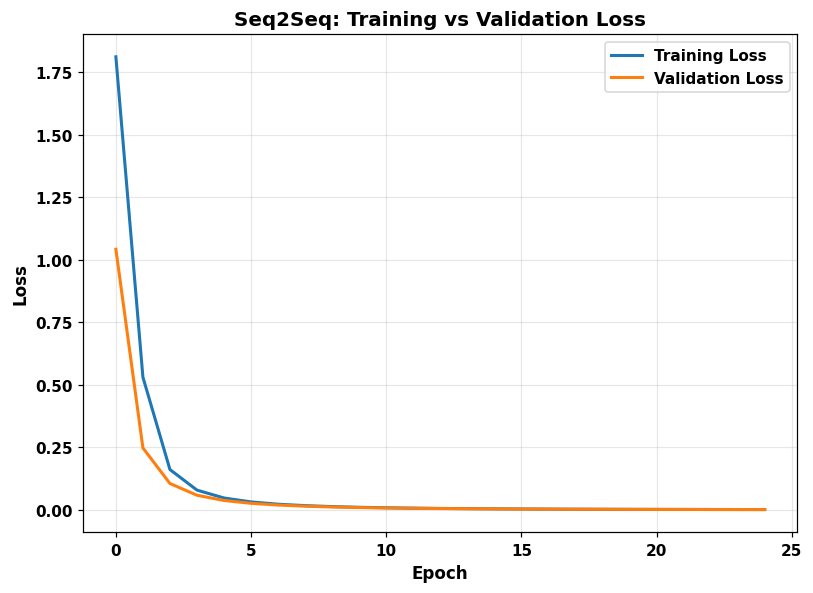

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(seq2seq_hist.history['loss'], label='Training Loss', linewidth=2)
ax.plot(seq2seq_hist.history['val_loss'], label='Validation Loss', linewidth=2)
style_axes(ax, title="Seq2Seq: Training vs Validation Loss", xlabel="Epoch", ylabel="Loss")
fig.tight_layout()
save_fig(fig, "plot10_seq2seq_loss.png")


In [ ]:
# ---- Inference-mode encoder/decoder (for autoregressive decoding at test time) ----
enc_inputs, encoder_states = enc_parts
dec_emb_layer, dec_lstm, dec_dense = dec_parts

encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_input_h = Input(shape=(ENC_UNITS,))
dec_state_input_c = Input(shape=(ENC_UNITS,))
dec_single_input = Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_input)
dec_single_out, dec_state_h, dec_state_c = dec_lstm(
    dec_single_emb, initial_state=[dec_state_input_h, dec_state_input_c])
dec_single_pred = dec_dense(dec_single_out)

decoder_model = models.Model(
    [dec_single_input, dec_state_input_h, dec_state_input_c],
    [dec_single_pred, dec_state_h, dec_state_c])

def decode_sequence(input_seq):
    states = encoder_model.predict(input_seq[np.newaxis, :], verbose=0)
    target = np.array([[START_TOKEN]])
    decoded = []
    for _ in range(SEQ_LEN):
        pred, h, c = decoder_model.predict([target] + states, verbose=0)
        next_token = int(np.argmax(pred[0, -1, :]))
        decoded.append(next_token)
        target = np.array([[next_token]])
        states = [h, c]
    return decoded


### Sample Predictions (5 test examples)

In [ ]:
sample_rows = []
for i in range(5):
    inp = Xs_te[i]
    pred = decode_sequence(inp)
    sample_rows.append({'Sample': i + 1,
                         'Input Sequence': list(inp),
                         'Predicted Output': pred,
                         'True Output': list(Ys_te[i])})
seq2seq_samples_df = pd.DataFrame(sample_rows)
seq2seq_samples_df


,Sample,Input Sequence,Predicted Output,True Output
0,1,"[0, 3, 9, 1]","[1, 9, 3, 0]","[1, 9, 3, 0]"
1,2,"[6, 8, 6, 9]","[9, 6, 8, 6]","[9, 6, 8, 6]"
2,3,"[2, 2, 6, 0]","[0, 6, 2, 2]","[0, 6, 2, 2]"
3,4,"[5, 7, 7, 6]","[6, 7, 7, 5]","[6, 7, 7, 5]"
4,5,"[2, 0, 7, 1]","[1, 7, 0, 2]","[1, 7, 0, 2]"


In [ ]:
# ---- Token accuracy and sequence accuracy over the full test set ----
all_preds = np.array([decode_sequence(Xs_te[i]) for i in range(len(Xs_te))])
token_acc = (all_preds == Ys_te).mean()
seq_acc = (all_preds == Ys_te).all(axis=1).mean()

print(f"Token Accuracy    : {token_acc*100:.2f}%")
print(f"Sequence Accuracy : {seq_acc*100:.2f}%")
print(f"Final Training Loss   : {seq2seq_hist.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {seq2seq_hist.history['val_loss'][-1]:.4f}")


Token Accuracy    : 100.00%
Sequence Accuracy : 100.00%
Final Training Loss   : 0.0008
Final Validation Loss : 0.0008


## 15. Consolidated Results (Section 25)

In [ ]:
consolidated = pd.DataFrame([
    {'Model': 'RNN',  'Accuracy (%)': eval_df.loc[eval_df.Model=='SimpleRNN','Accuracy (%)'].values[0],
     'Precision (%)': eval_df.loc[eval_df.Model=='SimpleRNN','Macro Precision (%)'].values[0],
     'Recall (%)': eval_df.loc[eval_df.Model=='SimpleRNN','Macro Recall (%)'].values[0],
     'F1 (%)': eval_df.loc[eval_df.Model=='SimpleRNN','Macro F1 (%)'].values[0],
     'Parameters': results['SimpleRNN']['params']},
    {'Model': 'LSTM', 'Accuracy (%)': eval_df.loc[eval_df.Model=='LSTM','Accuracy (%)'].values[0],
     'Precision (%)': eval_df.loc[eval_df.Model=='LSTM','Macro Precision (%)'].values[0],
     'Recall (%)': eval_df.loc[eval_df.Model=='LSTM','Macro Recall (%)'].values[0],
     'F1 (%)': eval_df.loc[eval_df.Model=='LSTM','Macro F1 (%)'].values[0],
     'Parameters': results['LSTM']['params']},
    {'Model': 'GRU',  'Accuracy (%)': eval_df.loc[eval_df.Model=='GRU','Accuracy (%)'].values[0],
     'Precision (%)': eval_df.loc[eval_df.Model=='GRU','Macro Precision (%)'].values[0],
     'Recall (%)': eval_df.loc[eval_df.Model=='GRU','Macro Recall (%)'].values[0],
     'F1 (%)': eval_df.loc[eval_df.Model=='GRU','Macro F1 (%)'].values[0],
     'Parameters': results['GRU']['params']},
])
if video_results:
    for rec_type, r in video_results.items():
        consolidated.loc[len(consolidated)] = {
            'Model': f'CNN-{rec_type}',
            'Accuracy (%)': round(r['accuracy']*100, 2),
            'Precision (%)': round(r['precision']*100, 2),
            'Recall (%)': round(r['recall']*100, 2),
            'F1 (%)': round(r['f1']*100, 2),
            'Parameters': np.nan,
        }
print("Table A — HAR classification models:")
display(consolidated)

seq2seq_table = pd.DataFrame([{
    'Task': 'Sequence Reversal (Seq2Seq)',
    'Token Accuracy (%)': round(token_acc*100, 2),
    'Sequence Accuracy (%)': round(seq_acc*100, 2),
    'Final Training Loss': round(seq2seq_hist.history['loss'][-1], 4),
    'Final Validation Loss': round(seq2seq_hist.history['val_loss'][-1], 4),
}])
print("Table B — Sequence-to-sequence task:")
display(seq2seq_table)


Table A — HAR classification models:


,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
0,RNN,80.44,81.24,80.44,80.42,1974.0
1,LSTM,94.00,94.04,94.00,93.99,6006.0
2,GRU,96.67,96.67,96.67,96.67,4758.0
3,CNN-LSTM,88.89,92.00,85.00,86.03,NaN
4,CNN-GRU,88.89,89.33,90.00,88.06,NaN


Table B — Sequence-to-sequence task:


,Task,Token Accuracy (%),Sequence Accuracy (%),Final Training Loss,Final Validation Loss
0,Sequence Reversal (Seq2Seq),100.0,100.0,0.0008,0.0008


## 16. Additional Exercises (Section 28) — All 7

### Exercise 1 — Recurrent units: 16 vs 32 vs 64

In [ ]:
unit_sweep_rows = []
for units in [16, 32, 64]:
    for m in ['SimpleRNN', 'LSTM', 'GRU']:
        model, hist, ttime, nparams = train_and_time(m, X_train_n, y_train, X_val_n, y_val,
                                                       epochs=20, verbose=0, units=units)
        ev = evaluate_model(model, X_test_n, y_test)
        unit_sweep_rows.append({'Units': units, 'Model': m,
                                 'Accuracy (%)': round(ev['accuracy']*100, 2),
                                 'F1 (%)': round(ev['f1']*100, 2),
                                 'Parameters': nparams,
                                 'Training Time (s)': round(ttime, 1)})
unit_sweep_df = pd.DataFrame(unit_sweep_rows)
unit_sweep_df


,Units,Model,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,16,SimpleRNN,71.78,70.83,790,20.4
1,16,LSTM,94.44,94.45,2038,17.4
2,16,GRU,93.78,93.76,1670,16.7
3,32,SimpleRNN,78.22,78.18,1974,21.6
4,32,LSTM,93.33,93.24,6006,17.3
5,32,GRU,94.00,93.97,4758,17.7
6,64,SimpleRNN,91.78,91.71,5878,21.4
7,64,LSTM,93.78,93.67,20086,17.3
8,64,GRU,92.67,92.50,15542,18.7


Saved: plots/ex1_units_vs_f1.png


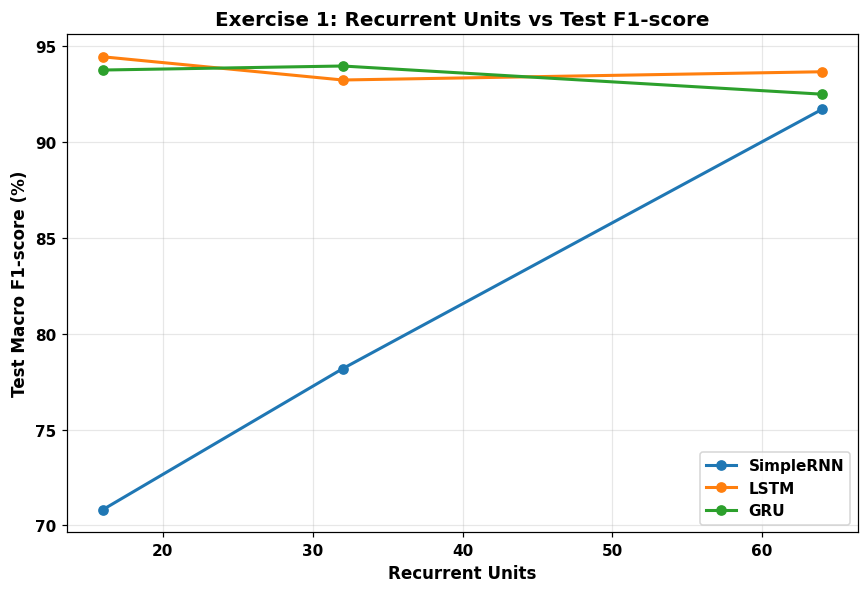

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for m in ['SimpleRNN', 'LSTM', 'GRU']:
    sub = unit_sweep_df[unit_sweep_df.Model == m]
    ax.plot(sub['Units'], sub['F1 (%)'], marker='o', linewidth=2, label=m)
style_axes(ax, title="Exercise 1: Recurrent Units vs Test F1-score", xlabel="Recurrent Units",
           ylabel="Test Macro F1-score (%)")
fig.tight_layout()
save_fig(fig, "ex1_units_vs_f1.png")


### Exercise 3 — Second recurrent layer

In [ ]:
for m in ['SimpleRNN', 'LSTM', 'GRU']:
    model, hist, ttime, nparams = train_and_time(m, X_train_n, y_train, X_val_n, y_val,
                                                   epochs=20, verbose=0, num_layers=2)
    ev = evaluate_model(model, X_test_n, y_test)
    print(f"{m} (2 layers): Accuracy={ev['accuracy']*100:.2f}%, F1={ev['f1']*100:.2f}%, "
          f"Params={nparams}, Time={ttime:.1f}s "
          f"(single-layer F1 was {results[m]['f1']*100:.2f}%)")


SimpleRNN (2 layers): Accuracy=84.67%, F1=84.48%, Params=4054, Time=32.6s (single-layer F1 was 80.42%)
LSTM (2 layers): Accuracy=95.78%, F1=95.77%, Params=14326, Time=24.0s (single-layer F1 was 93.99%)
GRU (2 layers): Accuracy=94.00%, F1=93.93%, Params=11094, Time=23.6s (single-layer F1 was 96.67%)


### Exercise 4 — Bidirectional vs Unidirectional LSTM

In [ ]:
model_uni, hist_uni, ttime_uni, nparams_uni = train_and_time(
    'LSTM', X_train_n, y_train, X_val_n, y_val, epochs=20, verbose=0, bidirectional=False)
ev_uni = evaluate_model(model_uni, X_test_n, y_test)

model_bi, hist_bi, ttime_bi, nparams_bi = train_and_time(
    'LSTM', X_train_n, y_train, X_val_n, y_val, epochs=20, verbose=0, bidirectional=True)
ev_bi = evaluate_model(model_bi, X_test_n, y_test)

print(f"Unidirectional LSTM : Acc={ev_uni['accuracy']*100:.2f}%, F1={ev_uni['f1']*100:.2f}%, "
      f"Params={nparams_uni}, Time={ttime_uni:.1f}s")
print(f"Bidirectional LSTM  : Acc={ev_bi['accuracy']*100:.2f}%, F1={ev_bi['f1']*100:.2f}%, "
      f"Params={nparams_bi}, Time={ttime_bi:.1f}s")


Unidirectional LSTM : Acc=94.00%, F1=93.99%, Params=6006, Time=18.3s
Bidirectional LSTM  : Acc=94.22%, F1=94.20%, Params=11894, Time=24.6s


### Exercise 5 — Sequence length vs computational cost

In [ ]:
print("Computational cost from the Section 12 sequence-length sweep (re-timed here for clarity):")
cost_rows = []
for T_use in seq_lengths:
    Xtr_t = truncate_seq(X_train_n, T_use)
    Xva_t = truncate_seq(X_val_n, T_use)
    for m in ['SimpleRNN', 'LSTM', 'GRU']:
        _, _, ttime, nparams = train_and_time(m, Xtr_t, y_train, Xva_t, y_val, epochs=10, verbose=0)
        cost_rows.append({'Sequence Length': T_use, 'Model': m,
                           'Training Time (s, 10 epochs)': round(ttime, 2)})
cost_df = pd.DataFrame(cost_rows)
cost_df.pivot(index='Sequence Length', columns='Model', values='Training Time (s, 10 epochs)')


Computational cost from the Section 12 sequence-length sweep (re-timed here for clarity):


Model,GRU,LSTM,SimpleRNN
Sequence Length,,,
32,7.66,6.84,10.65
64,7.32,8.52,10.95
128,9.24,12.40,13.25


### Exercise 7 — Seq2seq with different input/output lengths

In [ ]:
OUT_SEQ_LEN = 2   # e.g. output is only the first 2 reversed elements

def make_reversal_dataset_diff_len(n_samples, in_len=SEQ_LEN, out_len=OUT_SEQ_LEN, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(SEQ_VOCAB_MIN, SEQ_VOCAB_MAX + 1, size=(n_samples, in_len))
    Y = X[:, ::-1][:, :out_len]   # reversed, then truncated to a shorter output
    return X, Y

Xd, Yd = make_reversal_dataset_diff_len(N_SEQ_SAMPLES)
print("Example:", Xd[0], "-> (first", OUT_SEQ_LEN, "reversed) ->", Yd[0])

Xd_tr, Xd_te, Yd_tr, Yd_te = train_test_split(Xd, Yd, test_size=0.2, random_state=SEED)
Xd_tr, Xd_va, Yd_tr, Yd_va = train_test_split(Xd_tr, Yd_tr, test_size=0.1, random_state=SEED)

def make_decoder_io_diff(Y):
    n = Y.shape[0]
    dec_in = np.concatenate([np.full((n, 1), START_TOKEN), Y[:, :-1]], axis=1)
    return dec_in, Y

dec_in_tr_d, dec_out_tr_d = make_decoder_io_diff(Yd_tr)
dec_in_va_d, dec_out_va_d = make_decoder_io_diff(Yd_va)

def build_seq2seq_diff_len(in_len, out_len):
    enc_inputs = Input(shape=(in_len,))
    enc_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM)(enc_inputs)
    _, state_h, state_c = layers.LSTM(ENC_UNITS, return_state=True)(enc_emb)

    dec_inputs = Input(shape=(out_len,))
    dec_emb = layers.Embedding(VOCAB_SIZE, EMB_DIM)(dec_inputs)
    dec_outputs, _, _ = layers.LSTM(ENC_UNITS, return_sequences=True, return_state=True)(
        dec_emb, initial_state=[state_h, state_c])
    outputs = layers.Dense(VOCAB_SIZE, activation='softmax')(dec_outputs)

    model = models.Model([enc_inputs, dec_inputs], outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tf.keras.backend.clear_session()
seq2seq_diff_model = build_seq2seq_diff_len(SEQ_LEN, OUT_SEQ_LEN)
diff_hist = seq2seq_diff_model.fit(
    [Xd_tr, dec_in_tr_d], dec_out_tr_d,
    validation_data=([Xd_va, dec_in_va_d], dec_out_va_d),
    epochs=20, batch_size=64, verbose=0)
print("Final val accuracy (per-token, differing lengths):", diff_hist.history['val_accuracy'][-1])


Example: [6 3 7 4] -> (first 2 reversed) -> [4 7]
Final val accuracy (per-token, differing lengths): 1.0
